# Dropout Risk Classification Model (Leakage-Free Version)

This notebook retrains the dropout model while explicitly excluding all engineered variables used directly or indirectly in the `dropout_risk` definition.

The goal is to build a defensible predictive model.

The previous version included leakage through variables such as `dependency_risk`, `motivation_score`, and related derivatives.

This version uses only exogenous variables:
- Demographics
- AI usage behavior
- Organizational context

This model is more realistic, but performance may decrease.

## Feature Selection Rationale

The target `dropout_risk` was engineered using:
- `dependency_risk`
- `motivation_score`
- `self_efficacy_score`

Therefore, the following variables must be excluded to avoid target leakage.

Engineered scores excluded:
- `dependency_risk`
- `dependency_risk_high`
- `dependency_level`
- `motivation_score`
- `delta_motivation_score`
- `motivation_improved`
- `self_efficacy_score`
- `AT_mean`
- `D_mean`
- `E_mean`
- `composite_roi_score`
- `C3_inv`
- `C4_inv`

Psychometric blocks excluded:
- `C1`-`C4`
- `M1`-`M4`
- `AE1`-`AE4`

Including any of these variables would inject direct information from target construction and create target leakage.

In [1]:
# Import only allowed libraries and modules for this notebook.
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate


def _find_project_root(start_path: str) -> str:
    """Find project root by walking upward until .env and backend directory exist."""
    current = os.path.abspath(start_path)
    while True:
        env_candidate = os.path.join(current, '.env')
        backend_candidate = os.path.join(current, 'backend')
        if os.path.isfile(env_candidate) and os.path.isdir(backend_candidate):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise ValueError('Could not locate project root containing .env and backend directory.')


def _read_env_value(env_file: str, key: str) -> str:
    """Read one key from a .env file without external dependencies."""
    if not os.path.isfile(env_file):
        return ''
    with open(env_file, 'r', encoding='utf-8') as f:
        for line in f:
            raw = line.strip()
            if not raw or raw.startswith('#') or '=' not in raw:
                continue
            k, v = raw.split('=', 1)
            if k.strip() == key:
                return v.strip().strip('"').strip("'")
    return ''


# Resolve project root and .env path.
project_root = _find_project_root(os.getcwd())
env_path = os.path.join(project_root, '.env')

# Resolve engineered dataset directory from environment variables with fallback.
engineered_data_dir = os.getenv('ENGINEERED_DATA_DIR') or _read_env_value(env_path, 'ENGINEERED_DATA_DIR') or 'backend/data/processed'
if not os.path.isabs(engineered_data_dir):
    engineered_data_dir = os.path.join(project_root, engineered_data_dir)

# Build engineered dataset path and load it.
processed_path = os.path.join(engineered_data_dir, 'survey_engineered.csv')
if not os.path.exists(processed_path):
    raise FileNotFoundError(f'Engineered dataset not found at: {processed_path}')

df = pd.read_csv(processed_path)
print(f'Engineered dataset loaded from: {processed_path}')
print(f'Dataset shape: {df.shape}')

# Validate target column exists before modeling.
if 'dropout_risk' not in df.columns:
    raise ValueError("Required target column 'dropout_risk' not found in engineered dataset.")

Engineered dataset loaded from: /workspaces/EvaluAI/backend/data/processed/survey_engineered.csv
Dataset shape: (100, 55)


In [2]:
# Define leakage-free feature whitelist exactly as requested.
demographic_features = [
    'edad',
    'antiguedad_empresa',
    'rol_tecnico'
]

ai_usage_features = [
    'frecuencia_uso_ia',
    'usa_chatgpt',
    'usa_gemini',
    'usa_copilot',
    'usa_lms_ia',
    'usa_otra_ia',
    'prefiere_humano_vs_ia',
    'nivel_integracion_ia'
]

categorical_features = [
    'genero',
    'departamento',
    'sector',
    'nivel_educativo',
    'herramienta_principal'
]

# Ensure all required columns exist before proceeding.
required_columns = demographic_features + ai_usage_features + categorical_features + ['dropout_risk']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

# Build raw feature frame from whitelist only.
X_raw = df[demographic_features + ai_usage_features + categorical_features].copy()

# Convert numeric whitelisted columns explicitly to numeric and fill missing values.
numeric_whitelist = demographic_features + ai_usage_features
for col in numeric_whitelist:
    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')

# Fill numeric missing values with column median.
X_raw[numeric_whitelist] = X_raw[numeric_whitelist].fillna(X_raw[numeric_whitelist].median())

# Fill categorical missing values and apply one-hot encoding with drop_first=True.
X_raw[categorical_features] = X_raw[categorical_features].fillna('Unknown').astype(str)
X = pd.get_dummies(X_raw, columns=categorical_features, drop_first=True)

# Define target vector.
y = pd.to_numeric(df['dropout_risk'], errors='coerce').fillna(0).astype(int)

print(f'Leakage-free feature count: {X.shape[1]}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Leakage-free feature count: 28
X shape: (100, 28)
y shape: (100,)


In [3]:
# Initialize leakage-free RandomForestClassifier with requested parameters.
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Define stratified cross-validation strategy to preserve class ratios in folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define requested scoring metrics.
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Run cross-validation and return train scores for train-test gap analysis.
cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print('Cross-validation completed successfully.')

Cross-validation completed successfully.


In [4]:
# Compute metric summaries as mean ± standard deviation and train-test gaps.
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
summary_rows = []

for metric in metric_names:
    test_scores = cv_results[f'test_{metric}']
    train_scores = cv_results[f'train_{metric}']
    summary_rows.append({
        'metric': metric,
        'test_mean': float(np.mean(test_scores)),
        'test_std': float(np.std(test_scores)),
        'train_mean': float(np.mean(train_scores)),
        'train_std': float(np.std(train_scores)),
        'train_test_gap': float(np.mean(train_scores) - np.mean(test_scores))
    })

cv_summary = pd.DataFrame(summary_rows)

display_df = cv_summary.copy()
for col in ['test_mean', 'test_std', 'train_mean', 'train_std', 'train_test_gap']:
    display_df[col] = display_df[col].round(4)

print('Leakage-free CV summary (mean ± std):')
print(display_df.to_string(index=False))

# Interpretation note required by specification.
print('\nInterpretation: Lower performance than leakage version is expected and healthy.')

Leakage-free CV summary (mean ± std):
   metric  test_mean  test_std  train_mean  train_std  train_test_gap
 accuracy     0.5600    0.0583         1.0        0.0          0.4400
precision     0.6264    0.0352         1.0        0.0          0.3736
   recall     0.7474    0.1144         1.0        0.0          0.2526
       f1     0.6780    0.0569         1.0        0.0          0.3220
  roc_auc     0.4887    0.0916         1.0        0.0          0.5113

Interpretation: Lower performance than leakage version is expected and healthy.


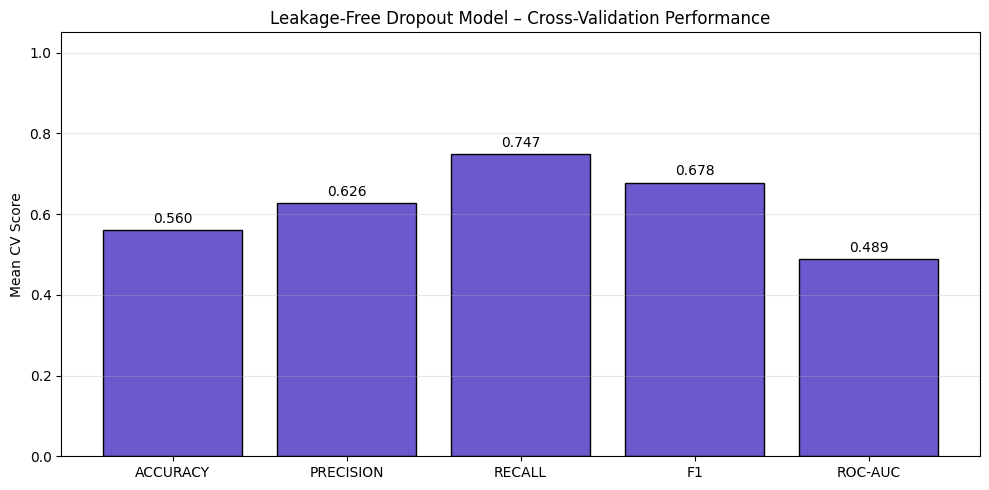

In [5]:
# Plot mean cross-validation metrics for the leakage-free model.
plot_df = cv_summary[['metric', 'test_mean']].copy()
plot_df['metric_label'] = plot_df['metric'].str.upper().replace({'ROC_AUC': 'ROC-AUC'})

plt.figure(figsize=(10, 5))
bars = plt.bar(plot_df['metric_label'], plot_df['test_mean'], color='slateblue', edgecolor='black')

# Add value labels on bars.
for bar, value in zip(bars, plot_df['test_mean']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{value:.3f}', ha='center', va='bottom')

plt.ylim(0, 1.05)
plt.ylabel('Mean CV Score')
plt.title('Leakage-Free Dropout Model – Cross-Validation Performance')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Train final model on all available leakage-free data.
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)

# Extract and sort feature importances.
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 10 features (leakage-free model):')
print(feature_importance_df.head(10).to_string(index=False))

Top 10 features (leakage-free model):
                   feature  importance
                      edad    0.138003
        antiguedad_empresa    0.103083
      nivel_integracion_ia    0.091013
     prefiere_humano_vs_ia    0.089866
         frecuencia_uso_ia    0.063816
herramienta_principal_Otra    0.037606
    nivel_educativo_Máster    0.035960
                usa_lms_ia    0.030183
genero_Prefiero no decirlo    0.026282
     nivel_educativo_Grado    0.026046


In [7]:
# Resolve MODEL_PATH from environment and .env with fallback.
model_dir = os.getenv('MODEL_PATH') or _read_env_value(env_path, 'MODEL_PATH') or 'backend/ml/models'
if not os.path.isabs(model_dir):
    model_dir = os.path.join(project_root, model_dir)

os.makedirs(model_dir, exist_ok=True)

# Save leakage-free model artifact.
model_path = os.path.join(model_dir, 'dropout_risk_model_clean.pkl')
joblib.dump(final_model, model_path)

# Build metadata payload.
cv_mean_metrics = {
    row['metric']: float(row['test_mean'])
    for _, row in cv_summary.iterrows()
}

metadata = {
    'model_type': 'RandomForestClassifier',
    'parameters': {
        'n_estimators': 200,
        'max_depth': 8,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'class_weight': 'balanced',
        'random_state': 42
    },
    'n_features': int(X.shape[1]),
    'feature_names': X.columns.tolist(),
    'class_distribution': {str(k): int(v) for k, v in y.value_counts(dropna=False).to_dict().items()},
    'CV metrics': cv_mean_metrics,
    'note': 'Leakage-free version',
    'timestamp': pd.Timestamp.utcnow().isoformat()
}

metadata_path = os.path.join(model_dir, 'dropout_risk_model_clean_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print(f'Model saved to: {model_path}')
print(f'Metadata saved to: {metadata_path}')

Model saved to: /workspaces/EvaluAI/backend/ml/models/dropout_risk_model_clean.pkl
Metadata saved to: /workspaces/EvaluAI/backend/ml/models/dropout_risk_model_clean_metadata.json


## Final Summary & Interpretation

This leakage-free model provides a more realistic estimate of predictive capability than the previous leakage-prone version.

Compared with the earlier model, some performance decrease is expected because direct proxy-construction variables were removed.

Business interpretation:
- Predictions are now driven by structural and behavioral context (demographics, usage, organization).
- This improves defensibility for HR and leadership decisions.

Limitations:
- The dataset size is small (100 samples).
- Metrics can be unstable across cohorts; retraining with new waves is recommended.

Model consumers:
- Backend `/predict` endpoint
- HR dashboard alerts
- Future AI coaching layer

This model reflects predictive capability based on structural and behavioral context,
not psychometric variables used to define the proxy itself.